# Studio 2 — Flair's Furniture, two ways 🪑🪚

**OPIM 5641 · Business Decision Modeling · Dr. Dave Wanik, UConn**

Tonight we solve **one** problem **two ways**: brute force, then the graphical method. Same problem,
same answer — one takes 361,251 plans, the other takes five points. You've seen both in the videos.
Now we build them.

Grab a pencil and paper. Seriously — the graphical half you draw first, Python second.

### The problem (from M2.2)

Flair Furniture makes **tables** and **chairs**. Each table takes **3 hours** of carpentry and
**2 hours** of painting. Each chair takes **4 hours** of carpentry and **1 hour** of painting. This
month there are **2,400 carpentry hours** and **1,000 painting hours**. Marketing says: **no more
than 450 chairs** (there's a pile of them already), and **at least 100 tables** (inventory is low).
A table brings in **\$7** of profit, a chair **\$5**.

How many of each should Flair make?

## 1 · The mathematical model

Write it down before you touch the keyboard. Every LP has the same three pieces.

**Decision variables** — what you get to decide:

$T$ = number of tables to make &nbsp;&nbsp; $C$ = number of chairs to make

**Objective function** — what you're maximizing:

$$Max\ Z = 7T + 5C$$

That 7 and that 5 are the **objective function coefficients**: profit per unit.

**Constraints** — the rules:

$$3T + 4C \le 2400 \quad \text{carpentry hours}$$
$$2T + 1C \le 1000 \quad \text{painting hours}$$
$$C \le 450 \quad \text{chair limit}$$
$$T \ge 100 \quad \text{table minimum}$$
$$T, C \ge 0 \quad \text{non-negativity}$$

## 2 · Soft-code the data

Map the story into dictionaries first. **Don't hard-code numbers into the loop.** Next year the
carpentry hours change, and you'd be hunting for a 2400 buried in your code, wondering what it meant.
Reference the data instead — and you'll make fewer typos while you're at it.

In [1]:
import numpy as np
import pandas as pd
from pylab import *   # for graphing, same as the M2.2 notebooks

# hours each product needs in each department
carpentry = {
    "tables" : 3,
    "chairs" : 4
}
painting = {
    "tables" : 2,
    "chairs" : 1
}

# hours available this month
total_time = {
    "carpentry" : 2400,
    "painting"  : 1000
}

# profit per unit  <- the objective function coefficients
profit = {
    "tables" : 7,
    "chairs" : 5
}

# what marketing insists on
limits = {
    "max_chairs" : 450,
    "min_tables" : 100
}

### How big is the search?

You need an upper bound for each loop, and you can reason it out of the data. Every table eats 3
carpentry hours, so you could never build more than $2400 / 3 = 800$ tables. Chairs are capped at
450 by marketing. Soft-code both — no stray numbers.

In [2]:
max_tables = total_time["carpentry"] // carpentry["tables"]   # 800 - all the carpentry hours, nothing else
max_chairs = limits["max_chairs"]                             # 450 - marketing's cap

# the +1 matters: range never includes the top, and building 800 tables IS a plan
(max_tables + 1) * (max_chairs + 1)

361251

## 3 · Brute force

Placeholders at the top — you're searching for the best profit, so start at zero and let the loop
overwrite them. Two decision variables means **two nested for loops**. Everything the constraints
need gets computed inside, and then **one big if** decides whether the plan is even legal.

In [3]:
best_profit = 0
best_tables = 0
best_chairs = 0
plans_checked = 0

for tables in np.arange(0, max_tables + 1, 1):        # 0 through 800 - the +1 puts 800 back in
    for chairs in np.arange(0, max_chairs + 1, 1):    # 0 through 450
        plans_checked = plans_checked + 1

        carpentry_hours = carpentry["tables"] * tables + carpentry["chairs"] * chairs
        painting_hours  = painting["tables"]  * tables + painting["chairs"]  * chairs

        if (carpentry_hours <= total_time["carpentry"] and
            painting_hours  <= total_time["painting"] and
            chairs <= limits["max_chairs"] and
            tables >= limits["min_tables"]):

            current_profit = profit["tables"] * tables + profit["chairs"] * chairs
            if current_profit > best_profit:
                best_profit = current_profit
                best_tables = tables
                best_chairs = chairs

print("Plans checked:", plans_checked)
print("Maximum profit:", best_profit)
print("tables:", best_tables)
print("chairs:", best_chairs)

Plans checked: 361251
Maximum profit: 4040
tables: 320
chairs: 360


Here's what you'd tell your boss: we looked at **every single plan** — all 361,251 of them — and
assuming the hours and the profits are right, this is the one that makes the most money. No clever
ideas required, nothing hidden. That's why brute force is worth knowing.

The catch: we checked a third of a million plans to find one, and almost all of them were junk. Now
watch the graph do it with five.

## 4 · Draw it by hand first

Pencil and paper. Tables on the x-axis, chairs on the y-axis. Label both every 200.

**Each constraint is the equation of a line**, and you get the line from two points: set one variable
to zero, then the other.

**Carpentry:** $3T + 4C = 2400$

Set $T = 0$:

$$\begin{aligned}
3(0) + 4C &= 2400\\
4C &= 2400\\
C &= 600
\end{aligned}$$

Set $C = 0$:

$$\begin{aligned}
3T + 4(0) &= 2400\\
3T &= 2400\\
T &= 800
\end{aligned}$$

So carpentry runs through $(0, 600)$ and $(800, 0)$.

**Painting:** $2T + 1C = 1000$

Set $T = 0$:

$$\begin{aligned}
2(0) + C &= 1000\\
C &= 1000
\end{aligned}$$

Set $C = 0$:

$$\begin{aligned}
2T + 0 &= 1000\\
2T &= 1000\\
T &= 500
\end{aligned}$$

So painting runs through $(0, 1000)$ and $(500, 0)$.

**Chair limit:** $C = 450$ — a horizontal line. **Table minimum:** $T = 100$ — a vertical line.

**Which side do you shade?** Try a test point. When in doubt use something easy like $(1, 1)$.
Is $3(1) + 4(1) = 7 \le 2400$? Yes — so $(1,1)$ is on the allowed side, and you shade the *other*
side, away from the origin. Do the same for painting. For $C \le 450$ you shade above the line;
for $T \ge 100$ you shade to the left.

Label every line as you draw it. Now here's the same picture in Python.

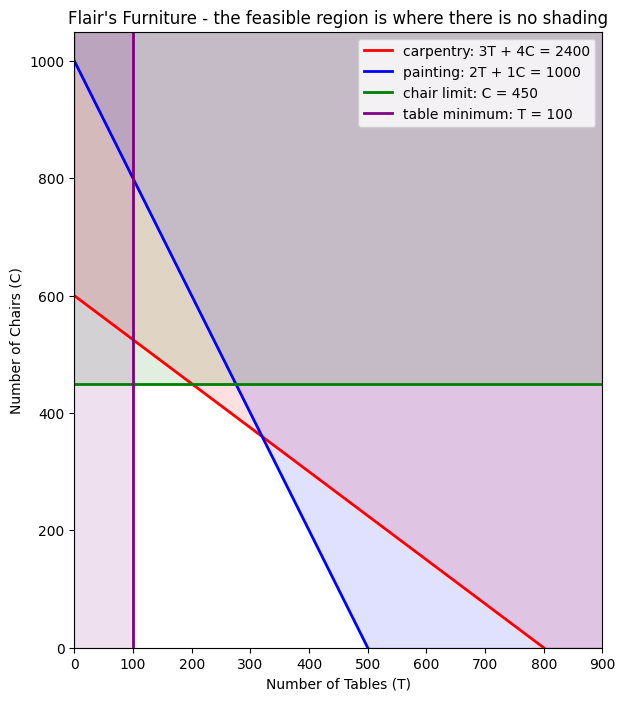

In [4]:
figure(figsize=(8, 8))
subplot(111, aspect='equal')
axis([0, 900, 0, 1050])
xlabel('Number of Tables (T)')
ylabel('Number of Chairs (C)')

# Carpentry: 3T + 4C = 2400  ->  (0, 600) and (800, 0)
plot([0, 800], [600, 0], 'r', lw=2, label='carpentry: 3T + 4C = 2400')   # label goes ON the line
fill_between([0, 800, 900], [600, 0, 0], [1050, 1050, 1050], color='red', alpha=0.12)

# Painting: 2T + 1C = 1000  ->  (0, 1000) and (500, 0)
plot([0, 500], [1000, 0], 'b', lw=2, label='painting: 2T + 1C = 1000')
fill_between([0, 500, 900], [1000, 0, 0], [1050, 1050, 1050], color='blue', alpha=0.12)

# Chair limit: C = 450, shade above
plot([0, 900], [450, 450], 'g', lw=2, label='chair limit: C = 450')
fill_between([0, 900], [450, 450], [1050, 1050], color='green', alpha=0.12)

# Table minimum: T = 100, shade to the left
plot([100, 100], [0, 1050], 'purple', lw=2, label='table minimum: T = 100')
axvspan(0, 100, color='purple', alpha=0.12)

legend(loc='upper right')
title("Flair's Furniture - the feasible region is where there is no shading")
savefig('fig_feasible_region.png')
show()

## 5 · The corner points

Where the constraints cordon off an unshaded area, that's the **feasible region** — every plan in
there is legal. The optimum is at a **corner**: anything inside is a linear combination of the
extremes, so the extremes are where the money is.

Five corners. Work around from the origin and **three of them are free**:

| | corner | how you get it |
|---|---|---|
| 1 | $(100, 0)$ | on the x-axis, at the table minimum |
| 2 | $(100, 450)$ | read it off: $T = 100$ crosses $C = 450$ |
| 5 | $(500, 0)$ | on the x-axis, where painting hits zero chairs |

The other two need algebra. **You're not allowed to eyeball it on an exam.**

**Corner 3 — carpentry meets the chair limit.** Drop the inequalities and solve the system:

$$\begin{aligned}
3T + 4C &= 2400\\
C &= 450
\end{aligned}$$

You already know $C$, so substitute it in and work down:

$$\begin{aligned}
3T + 4(450) &= 2400\\
3T + 1800 &= 2400\\
3T &= 2400 - 1800\\
3T &= 600\\
T &= 200
\end{aligned}$$

Corner 3 is $(200, 450)$.

**Corner 4 — carpentry meets painting.** This is the interesting one. Neither variable is handed to
you, so you have to make one disappear:

$$\begin{aligned}
3T + 4C &= 2400\\
2T + 1C &= 1000
\end{aligned}$$

Scale each line so the $T$ terms match. Multiply the top by 2 and the bottom by 3 — multiplying the
equation of a line by a constant gives you the *same line*, same slope, just scaled:

$$\begin{aligned}
2 \times (3T + 4C = 2400) \quad &\longrightarrow \quad 6T + 8C = 4800\\
3 \times (2T + 1C = 1000) \quad &\longrightarrow \quad 6T + 3C = 3000
\end{aligned}$$

Now stack them and subtract, column by column. The $T$ terms cancel — that was the whole point:

$$\begin{array}{rrcr}
 & 6T + 8C & = & 4800\\
- & (6T + 3C & = & 3000)\\
\hline
 & 0T + 5C & = & 1800
\end{array}$$

Term by term: $6T - 6T = 0T$, &nbsp; $8C - 3C = 5C$, &nbsp; $4800 - 3000 = 1800$. One variable left:

$$\begin{aligned}
5C &= 1800\\
C &= \frac{1800}{5}\\
C &= 360
\end{aligned}$$

Take that $C$ back to either original equation — carpentry is fine — and solve for $T$:

$$\begin{aligned}
3T + 4(360) &= 2400\\
3T + 1440 &= 2400\\
3T &= 2400 - 1440\\
3T &= 960\\
T &= 320
\end{aligned}$$

Corner 4 is $(320, 360)$. Squint at the graph — believable. Now **plug and chug**.

In [5]:
# the five corner points we solved for, one list per axis
corner_tables = [100, 100, 200, 320, 500]
corner_chairs = [  0, 450, 450, 360,   0]

best_profit = 0
best_tables = 0
best_chairs = 0

for i in range(0, len(corner_tables)):
    tables = corner_tables[i]
    chairs = corner_chairs[i]

    z = profit["tables"] * tables + profit["chairs"] * chairs
    print("corner: T =", tables, " C =", chairs, " -> Z =", z)

    if z > best_profit:
        best_profit = z
        best_tables = tables
        best_chairs = chairs

print()
print("Winner: T =", best_tables, " C =", best_chairs, " Z =", best_profit)

corner: T = 100  C = 0  -> Z = 700
corner: T = 100  C = 450  -> Z = 2950
corner: T = 200  C = 450  -> Z = 3650
corner: T = 320  C = 360  -> Z = 4040
corner: T = 500  C = 0  -> Z = 3500

Winner: T = 320  C = 360  Z = 4040


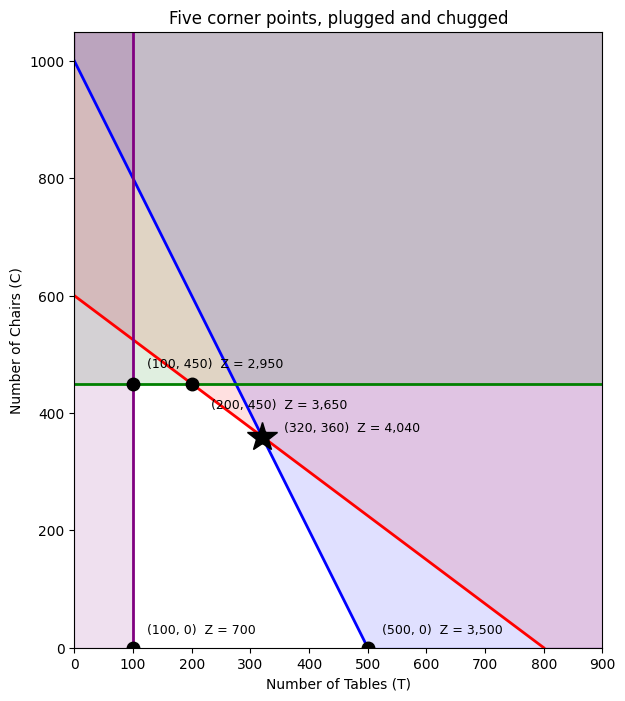

In [6]:
figure(figsize=(8, 8))
subplot(111, aspect='equal')
axis([0, 900, 0, 1050])
xlabel('Number of Tables (T)')
ylabel('Number of Chairs (C)')

plot([0, 800], [600, 0], 'r', lw=2)
fill_between([0, 800, 900], [600, 0, 0], [1050, 1050, 1050], color='red', alpha=0.12)
plot([0, 500], [1000, 0], 'b', lw=2)
fill_between([0, 500, 900], [1000, 0, 0], [1050, 1050, 1050], color='blue', alpha=0.12)
plot([0, 900], [450, 450], 'g', lw=2)
fill_between([0, 900], [450, 450], [1050, 1050], color='green', alpha=0.12)
plot([100, 100], [0, 1050], 'purple', lw=2)
axvspan(0, 100, color='purple', alpha=0.12)

# nudge each label so they don't sit on top of each other
label_x = [10, 10, 14, 16, 10]
label_y = [10, 12, -18, 4, 10]

for i in range(0, len(corner_tables)):
    tables = corner_tables[i]
    chairs = corner_chairs[i]
    z = profit["tables"] * tables + profit["chairs"] * chairs

    plot(tables, chairs, 'ko', markersize=9)
    annotate(f'({tables}, {chairs})  Z = {z:,}', (tables, chairs), fontsize=9,
             xytext=(label_x[i], label_y[i]), textcoords='offset points')

plot(320, 360, 'k*', markersize=22)
title('Five corner points, plugged and chugged')
savefig('fig_corners.png')
show()

## 6 · Two ways, one answer

| method | how many candidates | answer |
|---|---|---|
| brute force | 361,251 plans | 320 tables, 360 chairs, Z = 4,040 |
| graphical | 5 corner points | 320 tables, 360 chairs, Z = 4,040 |

From a third of a million combinations down to five interesting ones. That's the graphical method:
put the constraints on the graph as lines, shade to carve out the feasible region, solve the corner
points where constraints intersect, and plug them into the objective function.

And notice — a computer could do this too. If two constraints intersect, solve for the intersection
and store it. You could write that program yourself.

The downside: **it only works in two dimensions.** Three products and you're drawing in 3D; ten
products and there's no picture at all. What you need is an algebraic version of this same corner
walk — and that's the Simplex method, coming up next.

**Talk with your partner:**
1. At the winner, all 2,400 carpentry hours and all 1,000 painting hours are used up. What would one
   more carpentry hour be worth to Flair?
2. The chair limit ($C \le 450$) — did it end up mattering? How can you tell from the graph?

## 7 · Optional, if there's time: save it to GitHub

Same habit as Studio 1. Make a repo (something like `Studio2-BDM-F26-yourNetID`), then in Colab:
**File → Save a copy in GitHub**, pick that repo, and commit. Your two figures
(`fig_feasible_region.png`, `fig_corners.png`) go with it.

One save, and your work is in the repo, in Colab, and on your laptop.